---

# **<font color="#6767bf"> Modelación Climática Tropical</font>**
## **<font color="#8282d6"> Atlantic Multidecadal Variability </font>**
### **<font color="#a6a6f1"> Tendencias del residuo </font>**


---

In [1]:
pip install xarray

  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.8 MB/s eta 0:00:00:00:010:01
Using cached packaging-25.0-py3-none-any.whl (66 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 23.2
    Uninstalling packaging-23.2:
      Successfully uninstalled packaging-23.2
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install cftime

  Using cached cftime-1.6.5-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (8.7 kB)
Using cached cftime-1.6.5-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install h5netcdf

  Using cached h5netcdf-1.7.3-py3-none-any.whl.metadata (13 kB)
  Using cached h5py-3.15.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.0 kB)
Using cached h5netcdf-1.7.3-py3-none-any.whl (56 kB)
Using cached h5py-3.15.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (4.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install netCDF4 

  Using cached netcdf4-1.7.3-cp311-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.9 kB)
Using cached netcdf4-1.7.3-cp311-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install cartopy

  Using cached cartopy-0.25.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached pyshp-3.0.3-py3-none-any.whl.metadata (65 kB)
Using cached cartopy-0.25.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.8 MB)
Using cached pyshp-3.0.3-py3-none-any.whl (58 kB)
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import xarray as xr
import numpy as np
import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
from cartopy.util import add_cyclic_point
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import pandas as pd
import cftime
from scipy import stats
import glob

In [7]:
def lineplot_setup(xmin,xmax,xlab,ylab,ymin=None,ymax=None,title=None,legend=False):
    plt.xlim([xmin,xmax])
    plt.ylim([ymin,ymax])
    plt.grid(linestyle='--',alpha=0.66)
    plt.minorticks_on()
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel(xlab,fontsize=14)
    plt.ylabel(ylab,fontsize=14)
    plt.title(title,fontsize=14)
    if legend:
        plt.legend(fancybox=True,shadow=True,fontsize=10)

In [8]:
def mapa_MC(data, levels, ccmap, titulo, extend='both', cbarlabel='Anomalía  [mm día$^{-1}$]', 
            limite_NS=75, lon_min=None, lon_max=None, lat_min=None, lat_max=None):
    lons, lats = data.lon, data.lat
    data, lon = add_cyclic_point(data, coord=lons)
    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    cs = ax.contourf(lon, lats, data, levels=levels, cmap=ccmap, extend=extend, transform=ccrs.PlateCarree())

    if lon_min is not None and lon_max is not None and lat_min is not None and lat_max is not None:
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    else:
        ax.set_extent([0, 359.1, -limite_NS, limite_NS], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='k', linewidth=0.5)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    plt.title(titulo, fontsize=19)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.046, pad=0.06)
    cbar.ax.set_xlabel(cbarlabel)

In [9]:
#Abrimos indice
ds=xr.open_dataset('simulation_ocean_index.nc')

In [10]:
print(ds)

<xarray.Dataset> Size: 974kB
Dimensions:      (time: 1080, ens: 30, lat: 40, lon: 120)
Coordinates:
  * time         (time) datetime64[ns] 9kB 1921-01-16T12:00:00 ... 2010-12-16...
  * lat          (lat) float32 160B 20.5 21.5 22.5 23.5 ... 56.5 57.5 58.5 59.5
  * lon          (lon) float32 480B 120.5 121.5 122.5 ... 237.5 238.5 239.5
Dimensions without coordinates: ens
Data variables:
    AMO          (time, ens) float32 130kB ...
    PDO          (time, ens) float32 130kB ...
    PDO_pattern  (lat, lon, ens) float32 576kB ...
    NINO34       (time, ens) float32 130kB ...


In [11]:
Ens01=ds.AMO.sel(ens=14) #es el miembro siguiente, 0 es 1, 1 es 2...

In [12]:
Ens01.time

<xarray.DataArray 'time' (time: 1080)> Size: 9kB
array(['1921-01-16T12:00:00.000000000', '1921-02-15T00:00:00.000000000',
       '1921-03-16T12:00:00.000000000', ..., '2010-10-16T12:00:00.000000000',
       '2010-11-16T00:00:00.000000000', '2010-12-16T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 9kB 1921-01-16T12:00:00 ... 2010-12-16T12:...

In [13]:
#AMV_first_ensemble = ds.AMO.isel(ens=1) 

In [14]:
amv_df = Ens01.to_dataframe().reset_index()
amv_df

,time,AMO
0,1921-01-16 12:00:00,0.119113
1,1921-02-15 00:00:00,0.106766
2,1921-03-16 12:00:00,0.061405
3,1921-04-16 00:00:00,0.036451
4,1921-05-16 12:00:00,0.050824
...,...,...
1075,2010-08-16 12:00:00,0.276409
1076,2010-09-16 00:00:00,0.230305
1077,2010-10-16 12:00:00,0.307984
1078,2010-11-16 00:00:00,0.364184


In [15]:
#amv_df['rolled']=amv_df.rolling(120).mean()
amv_df['rolled'] = amv_df['AMO'].rolling(window=120, min_periods=60).mean()


In [16]:
amv_df['Date'] = pd.to_datetime(amv_df['time'].values)

In [17]:
amv_df['time']

0      1921-01-16 12:00:00
1      1921-02-15 00:00:00
2      1921-03-16 12:00:00
3      1921-04-16 00:00:00
4      1921-05-16 12:00:00
               ...        
1075   2010-08-16 12:00:00
1076   2010-09-16 00:00:00
1077   2010-10-16 12:00:00
1078   2010-11-16 00:00:00
1079   2010-12-16 12:00:00
Name: time, Length: 1080, dtype: datetime64[ns]

In [18]:
amv_JJAS = amv_df[amv_df['Date'].dt.month.isin([6, 7, 8, 9])]
amv_JJAS

,time,AMO,rolled,Date
5,1921-06-16 00:00:00,0.090232,NaN,1921-06-16 00:00:00
6,1921-07-16 12:00:00,0.119293,NaN,1921-07-16 12:00:00
7,1921-08-16 12:00:00,0.247413,NaN,1921-08-16 12:00:00
8,1921-09-16 00:00:00,0.193262,NaN,1921-09-16 00:00:00
17,1922-06-16 00:00:00,0.091568,NaN,1922-06-16 00:00:00
...,...,...,...,...
1064,2009-09-16 00:00:00,0.289050,0.252482,2009-09-16 00:00:00
1073,2010-06-16 00:00:00,0.196630,0.251132,2010-06-16 00:00:00
1074,2010-07-16 12:00:00,0.246982,0.249604,2010-07-16 12:00:00
1075,2010-08-16 12:00:00,0.276409,0.248765,2010-08-16 12:00:00


In [19]:
#amv_df[['Date', 'rolled']].to_csv('AMV02_suavizado.csv', index=False)

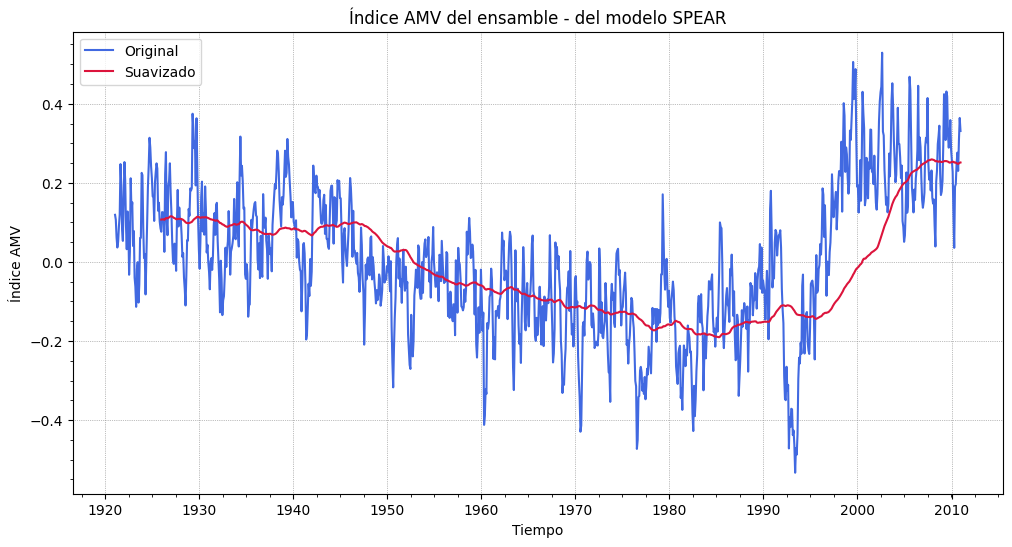

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(amv_df['Date'], amv_df['AMO'], label='Original', color="royalblue")  
plt.plot(amv_df['Date'], amv_df['rolled'], label='Suavizado', color='crimson')
plt.title('Índice AMV del ensamble - del modelo SPEAR')
plt.xlabel('Tiempo')
plt.ylabel('Índice AMV')
plt.grid(True, linestyle=':', linewidth='0.5', color='gray')
plt.minorticks_on()
plt.legend()
plt.show()

In [21]:
amv_df

,time,AMO,rolled,Date
0,1921-01-16 12:00:00,0.119113,NaN,1921-01-16 12:00:00
1,1921-02-15 00:00:00,0.106766,NaN,1921-02-15 00:00:00
2,1921-03-16 12:00:00,0.061405,NaN,1921-03-16 12:00:00
3,1921-04-16 00:00:00,0.036451,NaN,1921-04-16 00:00:00
4,1921-05-16 12:00:00,0.050824,NaN,1921-05-16 12:00:00
...,...,...,...,...
1075,2010-08-16 12:00:00,0.276409,0.248765,2010-08-16 12:00:00
1076,2010-09-16 00:00:00,0.230305,0.247866,2010-09-16 00:00:00
1077,2010-10-16 12:00:00,0.307984,0.249238,2010-10-16 12:00:00
1078,2010-11-16 00:00:00,0.364184,0.250947,2010-11-16 00:00:00


In [22]:
filename='/home/jovyan/ModClim/SPEAR/monthly_ens015.nc' #este miembro si es 
ds=xr.open_dataset(filename)
pr=ds['precip']
pr= pr* 86400  
pr['units'] = 'mm day-1'

In [23]:
lons=pr.lon
lats=pr.lat

In [24]:
# Tenemos que obtener el promedio de los años con AMO
yearsel=pr.sel(time=slice('1926', '2010'))

time_yrsprep=yearsel.where((pr.time.dt.month >= 6) & (pr.time.dt.month <= 9), drop=True)

#print(pr_jjas)
time_yrsprep

<xarray.DataArray 'precip' (time: 340, lat: 90, lon: 104)> Size: 13MB
array([[[ 0.2520131 ,  0.230701  ,  0.21789046, ...,  4.0610056 ,
          6.2423143 , 10.784515  ],
        [ 0.24055113,  0.23099706,  0.2373715 , ...,  5.556841  ,
          8.226136  , 14.098199  ],
        [ 0.21047206,  0.23552537,  0.23823401, ...,  8.648678  ,
         10.030305  , 15.723424  ],
        ...,
        [ 1.0886717 ,  1.88278   ,  2.4829478 , ...,  7.1812944 ,
          7.280619  ,  6.932719  ],
        [ 0.84471697,  1.4488624 ,  2.4714425 , ...,  7.373597  ,
          7.4922767 ,  7.4734077 ],
        [ 0.78129005,  1.3974109 ,  2.200358  , ...,  5.556007  ,
          5.9470263 ,  6.2471285 ]],

       [[ 0.11297137,  0.12844166,  0.13164388, ...,  3.172777  ,
          2.710163  ,  1.8940537 ],
        [ 0.10961752,  0.11242314,  0.10454169, ...,  4.986039  ,
          5.079057  ,  3.1507947 ],
        [ 0.12650238,  0.11684522,  0.12207378, ...,  6.3944783 ,
          7.288571  ,  5.5617895 ],
...
        [ 1.438613  ,  1.4947617 ,  1.2351108 , ...,  9.271356  ,
         10.636262  , 12.031746  ],
        [ 0.67746747,  0.58144265,  0.5057547 , ...,  8.748249  ,
          8.593536  ,  8.622274  ],
        [ 0.1699538 ,  0.25306967,  0.42746216, ...,  8.519028  ,
          6.4398947 ,  5.296248  ]],

       [[ 0.20286831,  0.21059953,  0.23469059, ...,  2.1753006 ,
          1.730473  ,  1.2898821 ],
        [ 0.1345121 ,  0.15650438,  0.1742889 , ...,  1.8576862 ,
          1.4073006 ,  1.069987  ],
        [ 0.11644246,  0.13556793,  0.16446036, ...,  1.4719772 ,
          1.1627029 ,  1.369052  ],
        ...,
        [ 1.650535  ,  2.237961  ,  1.8828007 , ...,  3.0161116 ,
          3.263691  ,  3.97659   ],
        [ 1.4723507 ,  2.0641506 ,  2.3593888 , ...,  2.720915  ,
          2.474488  ,  3.1309197 ],
        [ 1.686411  ,  2.4381688 ,  2.7909896 , ...,  3.3564475 ,
          2.6812603 ,  2.6722333 ]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1926-06-16 ... 2010-09-16
  * lat      (lat) float64 720B -0.75 -0.25 0.25 0.75 ... 42.75 43.25 43.75
  * lon      (lon) float64 832B 235.3 235.9 236.6 237.2 ... 298.4 299.1 299.7
    units    <U8 32B 'mm day-1'
Attributes:
    long_name:      Total precipitation rate
    units:          kg/m2/s
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    interp_method:  conserve_order1

In [25]:
# Seleccionamos el área especifica
pr_jjas_centromex = time_yrsprep.sel(lat=slice(13.75, 23.75), lon=slice(253.75, 273.5))
#pr_jjas_centromex=pr_jjas_centromex.mean()
pr_jjas_prom_centromex = pr_jjas_centromex.mean(dim=["lat", "lon"]) #skipna=True

pr_jjas_prom_centromex_anual=pr_jjas_prom_centromex.groupby('time.year').mean('time')

pr_jjas_prom_centromex_anual

<xarray.DataArray 'precip' (year: 85)> Size: 340B
array([7.812392 , 7.6537023, 5.089056 , 8.666294 , 8.838716 , 6.4913273,
       4.605355 , 6.9968004, 8.539725 , 7.3650312, 7.702675 , 6.5174026,
       7.2207804, 7.6677   , 8.471406 , 6.1680236, 7.7751126, 7.5625286,
       7.664038 , 6.9226856, 5.762041 , 5.722884 , 6.614595 , 6.1695957,
       6.7406225, 6.361072 , 6.8336377, 6.679114 , 6.3507967, 6.8171244,
       6.239909 , 7.167227 , 7.1335983, 6.245446 , 5.7447743, 5.5673275,
       7.901791 , 5.125399 , 6.8162804, 7.662827 , 6.478528 , 5.6515164,
       8.176484 , 8.1062975, 6.690298 , 5.839145 , 5.21298  , 6.1144495,
       5.7786884, 7.2496805, 6.1430206, 5.19893  , 5.7755404, 7.2973948,
       7.2318387, 7.2721343, 4.701824 , 6.8172784, 7.8192167, 8.213217 ,
       8.384684 , 5.8011456, 5.7055874, 6.500868 , 8.12887  , 5.5728693,
       6.2585034, 5.688349 , 6.111565 , 6.4029417, 8.585466 , 8.530164 ,
       5.8194337, 8.097524 , 6.1124125, 5.161609 , 6.0677505, 6.136844 ,
       5.3341703, 6.747467 , 9.678606 , 7.950861 , 6.2795854, 6.212657 ,
       8.270296 ], dtype=float32)
Coordinates:
  * year     (year) int64 680B 1926 1927 1928 1929 1930 ... 2007 2008 2009 2010
    units    <U8 32B 'mm day-1'
Attributes:
    long_name:      Total precipitation rate
    units:          kg/m2/s
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    interp_method:  conserve_order1

In [26]:
years_amv = [1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 
1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 
1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 
1975, 1976, 1977, 1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010]
df_filtrado = amv_JJAS[amv_JJAS['Date'].dt.year.isin(years_amv)]


df_filtrado['year'] = df_filtrado['Date'].dt.year
promedios_amv = df_filtrado.groupby('year')['rolled'].mean()
print(promedios_amv)

year
1926    0.110745
1927    0.108651
1928    0.100133
1929    0.110421
1930    0.112863
          ...   
2006    0.239500
2007    0.256933
2008    0.254137
2009    0.253902
2010    0.249342
Name: rolled, Length: 85, dtype: float64


/tmp/ipykernel_556/835245785.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['year'] = df_filtrado['Date'].dt.year


In [27]:
print(len(promedios_amv), len(pr_jjas_prom_centromex_anual))  # Deberían ser iguales

85 85


In [28]:
x = promedios_amv.values.astype(float)
y = pr_jjas_prom_centromex_anual.values.astype(float)

In [29]:
x

array([ 0.11074507,  0.10865117,  0.10013284,  0.11042114,  0.11286285,
        0.10540187,  0.09349531,  0.09450861,  0.10115796,  0.08076423,
        0.07480538,  0.07039443,  0.08258125,  0.0844114 ,  0.08091404,
        0.07258679,  0.08264895,  0.09227819,  0.08956343,  0.09849935,
        0.09995897,  0.09179524,  0.07383715,  0.04670764,  0.03015495,
        0.02963843,  0.00729106, -0.01291801, -0.02529041, -0.03717316,
       -0.04891185, -0.05496782, -0.05849781, -0.05552971, -0.06930756,
       -0.07736265, -0.06990975, -0.06994791, -0.08115036, -0.08623389,
       -0.09720061, -0.09815368, -0.1025925 , -0.11432063, -0.11379816,
       -0.11086041, -0.12138389, -0.12982389, -0.12753106, -0.13085981,
       -0.13880611, -0.1606631 , -0.17100672, -0.16151287, -0.15087217,
       -0.1666753 , -0.17698481, -0.18147591, -0.18581339, -0.18376026,
       -0.17153062, -0.15771724, -0.15267098, -0.15348074, -0.15040831,
       -0.11996729, -0.11019104, -0.13243057, -0.13886118, -0.14

In [30]:
years = np.arange(1926, 2011)

In [31]:
X2=x
y2=y

In [32]:
print(len(X2), len(y2))  # Deberían ser iguales

85 85


In [33]:
# Coeficientes
m2 = np.sum((X2 - X2.mean()) * (y2 - y2.mean())) / np.sum((X2 - X2.mean())**2)
b2 = y2.mean() - m2 * X2.mean()
predicciones2 = m2 * X2 + b2      #predicciones 

In [34]:
residual = y2 - predicciones2
# Calcular pendiente y la intersección 
m4 = np.sum((years - np.mean(years)) * (residual - np.mean(residual))) / np.sum((years - np.mean(years))**2)
b4 =  np.mean(residual) - m4 * np.mean(years)
predicciones= b4 + m4 * years
m4_siglo=m4*100
#np.save("pendiente_030_SPEAR_sinAMV.npy", m4_siglo)
m4_siglo

np.float64(-0.2438287987082366)

In [35]:
from statistics import correlation

r=correlation(X2, y2)

print(r)
#round(r,2)
#np.save('correlacion_030_SPEAR_.npy',r)

0.17586479454468973


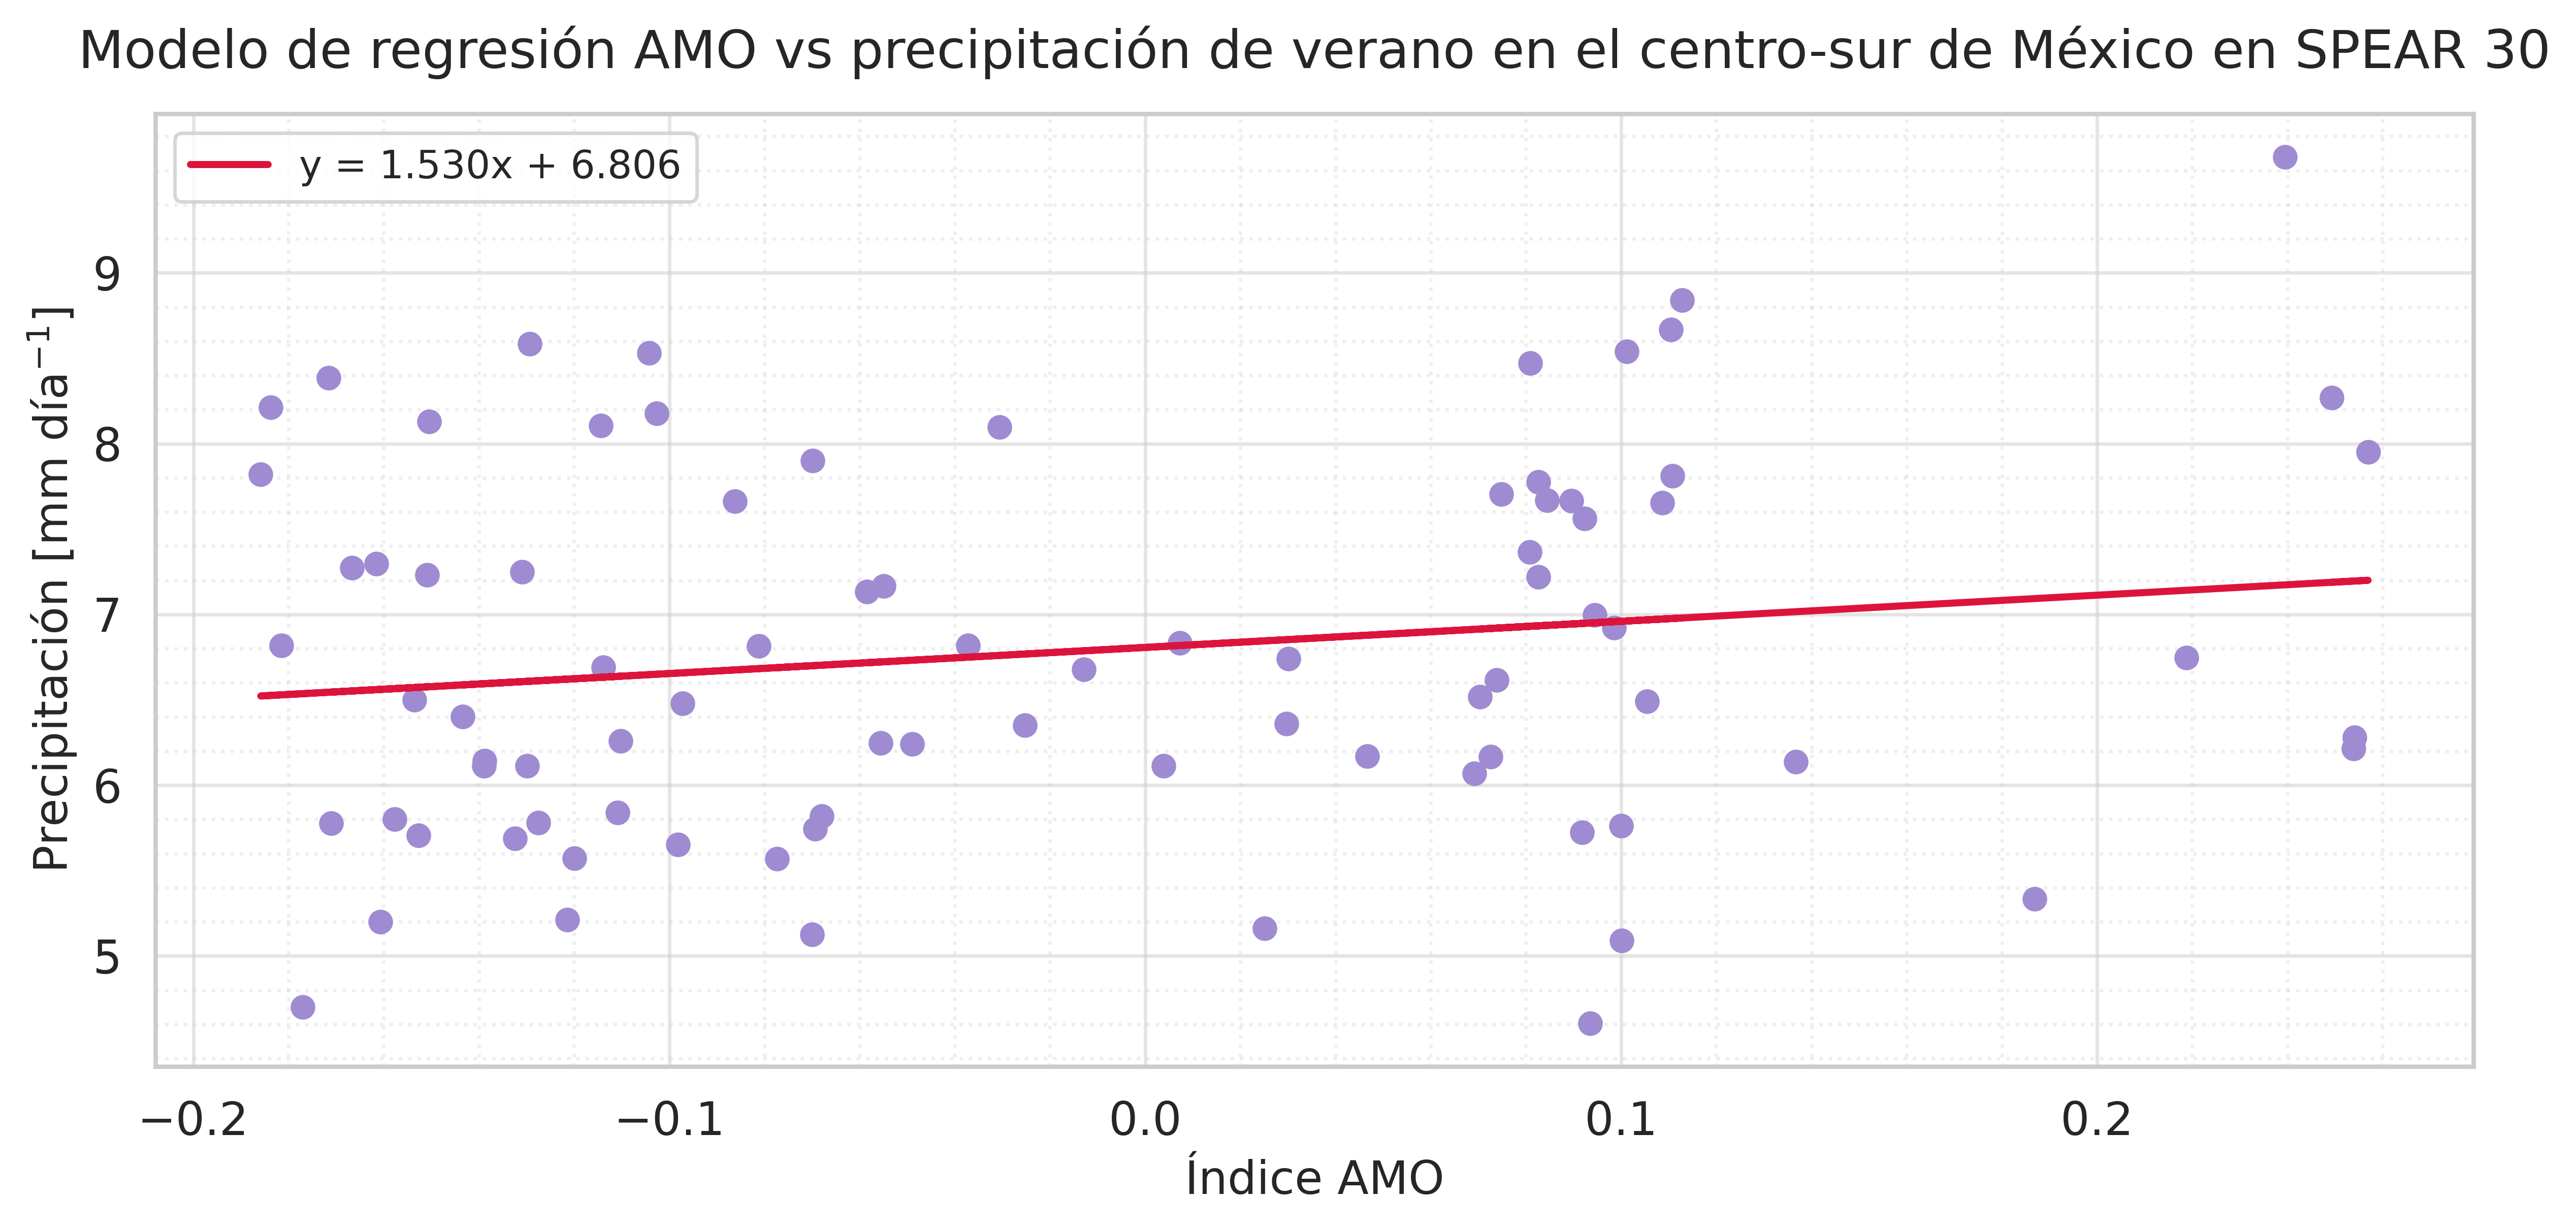

In [36]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5), dpi=500)
plt.scatter(x, y, color='#9f8bd1')
plt.plot(X2, predicciones2, color='crimson', linewidth=2, label=f'y = {m2:.3f}x + {b2:.3f}')
# Etiquetas
plt.xlabel('Índice AMO', fontsize=13)
plt.ylabel('Precipitación [mm día$^{-1}$]', fontsize=13)
plt.title('Modelo de regresión AMO vs precipitación de verano en el centro-sur de México en SPEAR 30',fontsize=15 ,pad=13, x=0.5)
plt.grid(True, which='major', linestyle='-', alpha=0.5)  
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', alpha=0.3)  
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.grid(True)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

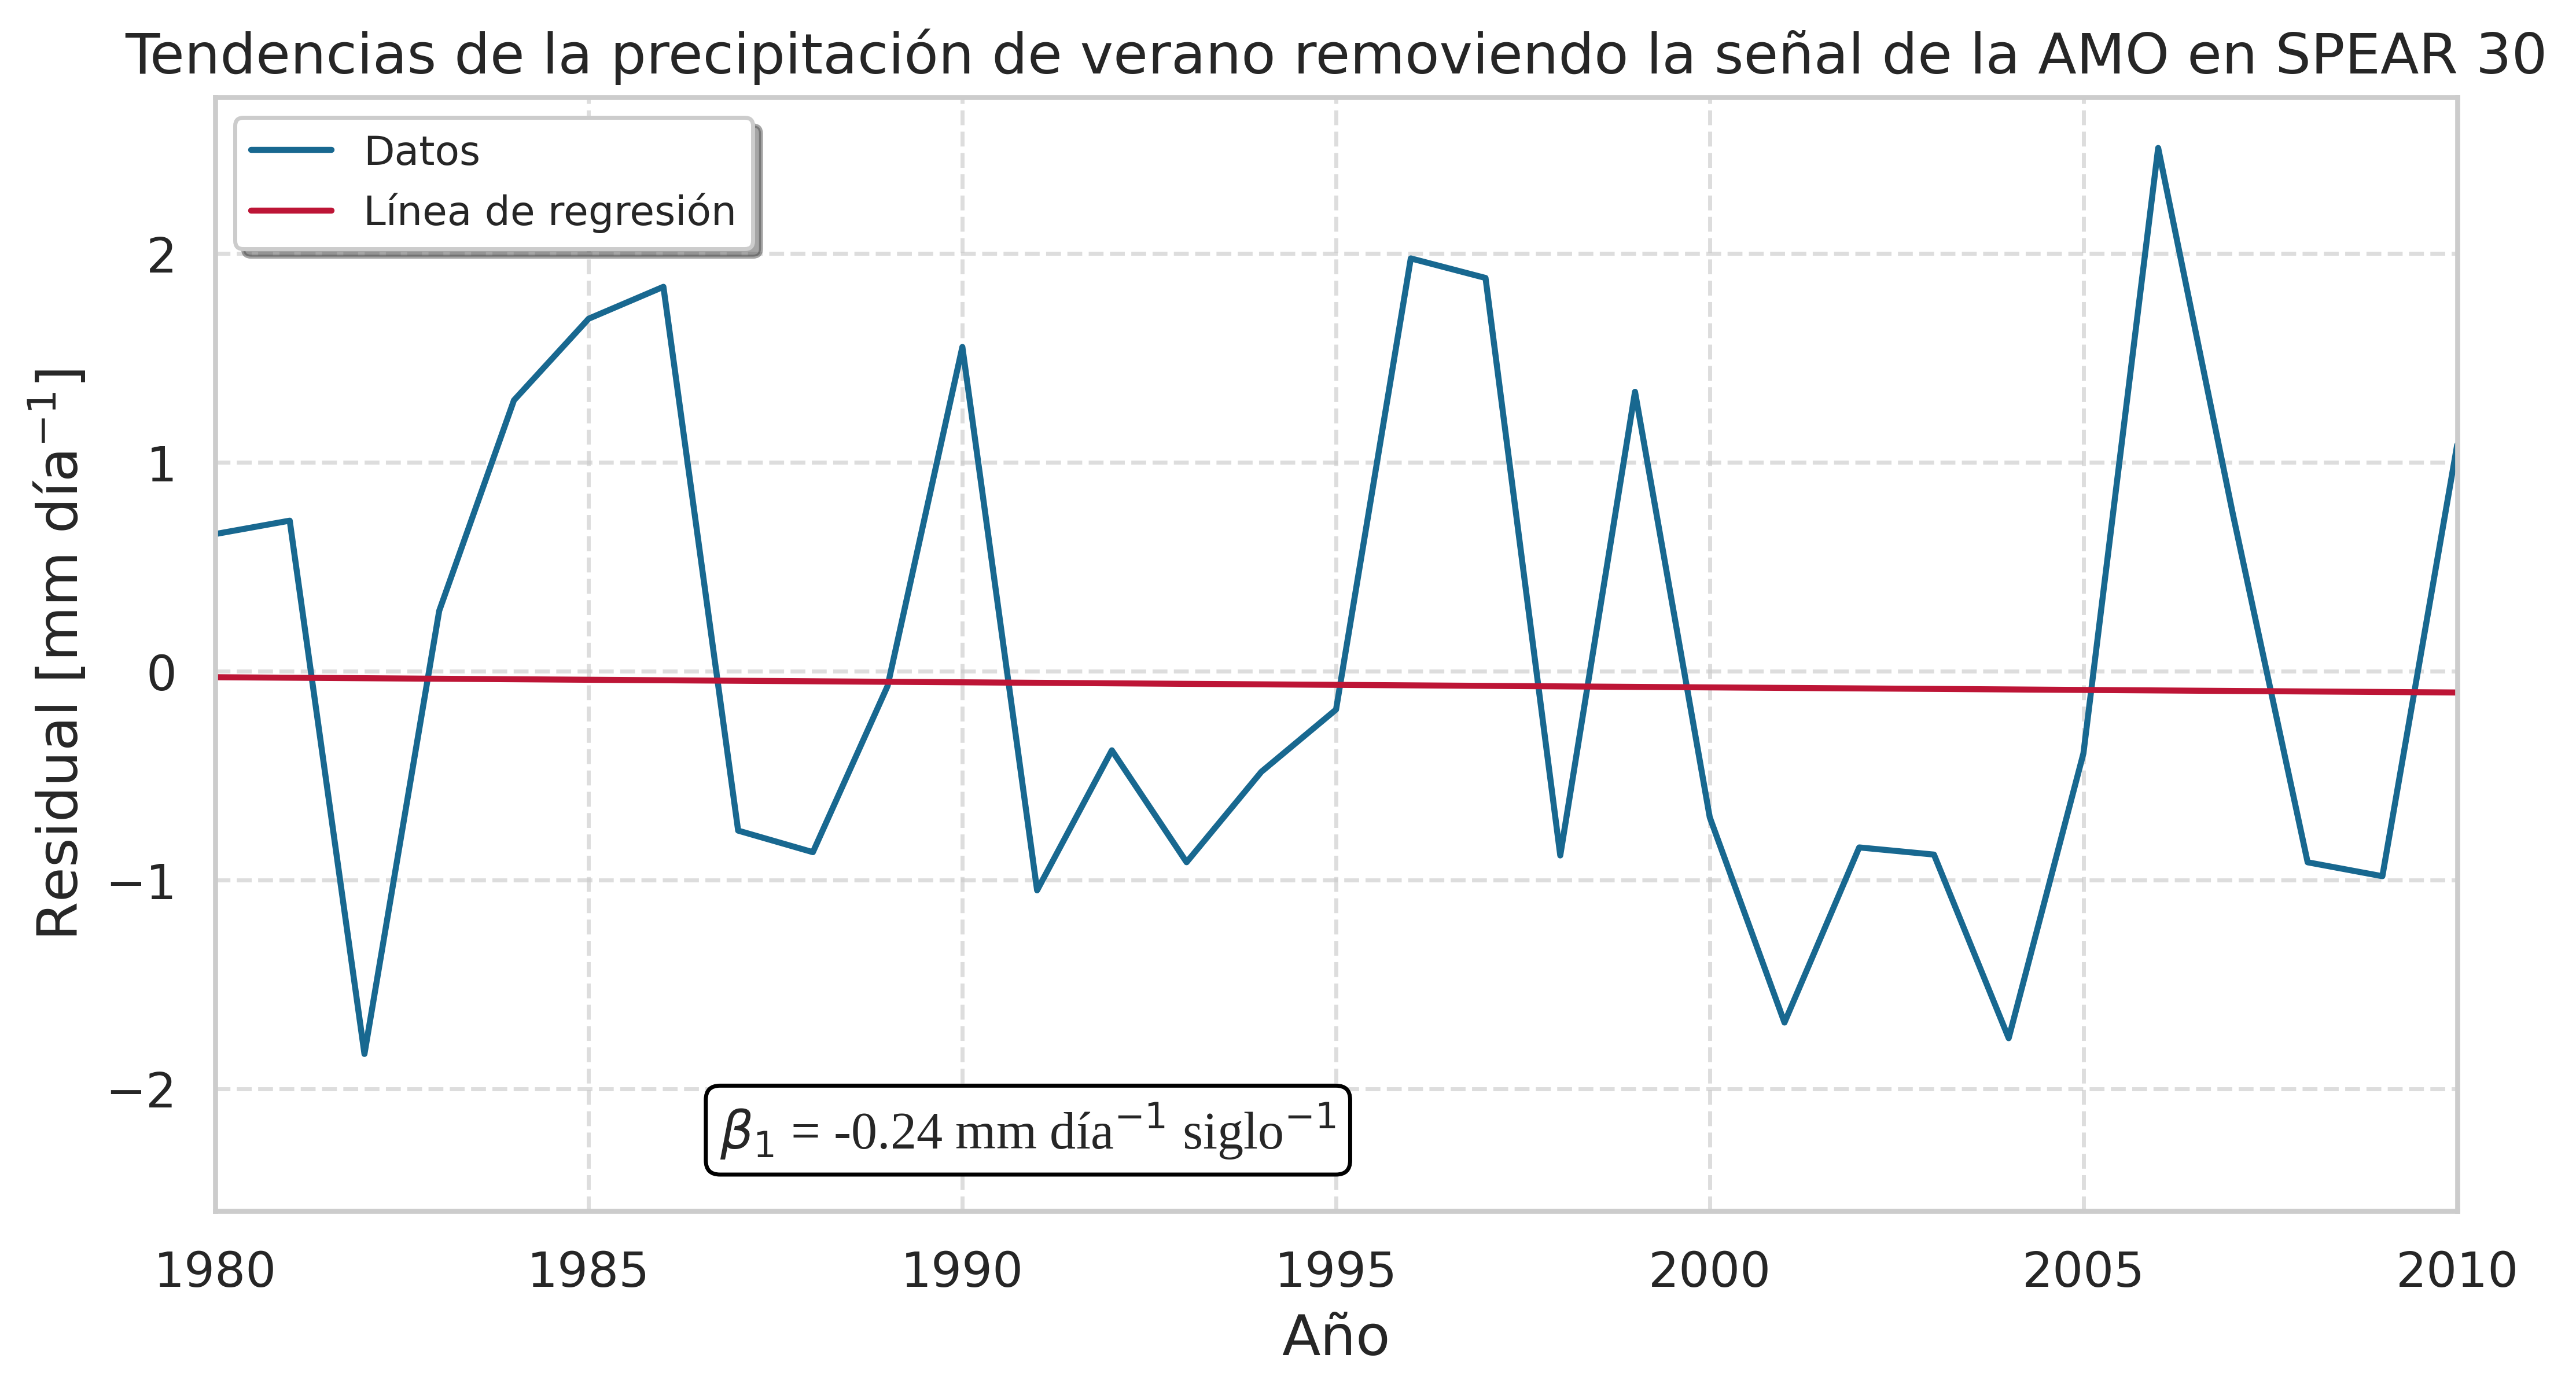

In [37]:
from matplotlib.lines import Line2D

# Graficamos los datos y la línea de regresión
plt.figure(figsize=(10,5), dpi=500)
plt.plot(years, residual, color='#186890', label='Datos')
plt.plot(years, predicciones, color='#bd1536', label='Línea de regresión')
#plt.text(0.05, 0.95, 'd)', transform=plt.gca().transAxes, fontsize=17, fontname='Liberation Serif', fontweight='bold', va='top', ha='right',
 #       bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.27', linewidth=1))
lineplot_setup(1980,2010,'Año','Residual [mm día$^{-1}$]',title='Tendencias de la precipitación de verano removiendo la señal de la AMO en SPEAR 30',legend=True)

plt.text(0.5, 0.1,f"$\\beta_1$ = {m4_siglo:.2f} mm día$^{{-1}}$ siglo$^{{-1}}$", transform=plt.gca().transAxes, fontsize=13, fontname='Liberation Serif', fontweight='normal', va='top', ha='right',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.27',linewidth=1))

ax = plt.gca() 

## Tendencias antes y después de remover la señal de la AMO


In [38]:
#tendencias originales
pendiente_GPCC=np.load("pendiente_GPCC (1).npy")
pendiente_GPCP=np.load("pendiente_GPCP (1).npy")
pendiente_MSWEP=np.load("pendiente_MSWEP (1).npy")
pendiente_spear80=np.load('pendiente_SPEAR_ens_1980 (1).npy')
pendiente_spear26=np.load('pendiente_SPEAR_ens_1921 (1).npy')

In [39]:
#pendientes originales spear
tendencias = []
for i in range(1, 31):
    file = f'pendientes/pendiente_0{i}_SPEAR.npy'
    data = np.load(file)
    tendencias.append(data)

tendencias_100 = [val * 100 for val in tendencias]
tendencias_100

[np.float64(-0.3118381575997996),
 np.float64(0.2957419699129462),
 np.float64(-0.37087874838995505),
 np.float64(0.11127990072350613),
 np.float64(-0.16812646065679906),
 np.float64(0.01127692698038973),
 np.float64(0.19903968939463454),
 np.float64(0.09460810913972689),
 np.float64(0.6823411976775451),
 np.float64(-0.3871156363034487),
 np.float64(-0.2381969653181899),
 np.float64(0.16590804157224895),
 np.float64(0.05201211528885623),
 np.float64(-0.23916758769538887),
 np.float64(-0.20239448932020165),
 np.float64(-0.4780961688361541),
 np.float64(0.1647832573512584),
 np.float64(0.6712980027423894),
 np.float64(0.40103421052473587),
 np.float64(0.5419375591574026),
 np.float64(0.9263415375270829),
 np.float64(-0.6763747337301429),
 np.float64(0.13541686700225175),
 np.float64(0.10113701759731199),
 np.float64(0.3905601178039056),
 np.float64(0.2169725495257701),
 np.float64(-0.07338868603665342),
 np.float64(0.12353712577174543),
 np.float64(0.1848472253419727),
 np.float64(-0.088

In [40]:
#pendientes sin amv
pendiente_GPCC_sinAMV=np.load("pendiente_GPCC_sinAMV.npy")
pendiente_GPCP_sinAMV=np.load("pendiente_GPCP_sinAMV.npy")
pendiente_MSWEP_sinAMV=np.load("pendiente_MSWEP_sinAMV.npy")
pendiente_SPEAR_26_sinAMV=np.load("pendiente_mean26_SPEAR_sinAMV.npy")
pendiente_SPEAR_80_sinAMV=np.load("pendiente_mean80_SPEAR_sinAMV.npy")

In [41]:
tendencias_noAMV=np.load("pendiente_03_SPEAR_sinAMV.npy")
tendencias_noAMV

array(-0.4276181)

In [42]:
#pendientes sin amv spear
#pendientes originales spear
tendencias_noAMV = []
for i in range(1, 31):
    file = f'pendiente_0{i}_SPEAR_sinAMV.npy'
    data = np.load(file)
    tendencias_noAMV.append(data)

tendencias_noAMV= np.array(tendencias_noAMV, dtype=float).tolist()
tendencias_noAMV

[-0.4789416458700559,
 0.025731591066873692,
 -0.42761809962555963,
 0.5382512008370403,
 -0.03591335295239869,
 -0.03073651116372895,
 -0.25221679001420094,
 0.574683302171247,
 0.48977142703243665,
 -0.558725035798803,
 -0.07756379294193547,
 0.44191808229380997,
 0.24545106266446434,
 -0.1207014143466519,
 -0.2438287987082366,
 -0.46709983106894776,
 0.29603379363142224,
 0.652441340477018,
 0.26716496490132313,
 0.3757187915446171,
 1.1635275199464774,
 -0.49060099747036845,
 0.24297147399906957,
 0.49943813178987456,
 0.5613154760185513,
 0.35406390921625586,
 -0.11546322495978759,
 -0.1465748473897467,
 0.22411550628266863,
 0.0076662501249975925]

sns.set(style="whitegrid")
plt.figure(figsize=(15, 8), dpi=500)

plt.scatter([0], tendencias[0]*100, color='slateblue', marker='H', s=74)#, label='Miembro 01')  
plt.scatter([1], tendencias[11]*100, color='slateblue', marker='H', s=74)#, label='Miembro 02')  
plt.scatter([2], tendencias[22]*100, color='slateblue', marker='H', s=74)#, label='Miembro 03')  
plt.scatter([3], tendencias[24]*100, color='slateblue', marker='H', s=74)#, label='Miembro 04')  
plt.scatter([4], tendencias[25]*100, color='slateblue', marker='H', s=74)#, label='Miembro 05')  
plt.scatter([5], tendencias[26]*100, color='slateblue', marker='H', s=74)#, label='Miembro 06')  
plt.scatter([6], tendencias[27]*100, color='slateblue', marker='H', s=74)#, label='Miembro 07')  
plt.scatter([7], tendencias[28]*100, color='slateblue', marker='H', s=74)#, label='Miembro 08')  
plt.scatter([8], tendencias[29]*100, color='slateblue', marker='H', s=74)#, label='Miembro 09')  
plt.scatter([9], tendencias[1]*100, color='slateblue', marker='H', s=74)#, label='Miembro 10')  
plt.scatter([10], tendencias[2]*100, color='slateblue', marker='H', s=74)#, label='Miembro 11')  
plt.scatter([11], tendencias[3]*100, color='slateblue', marker='H', s=74)#, label='Miembro 12')
plt.scatter([12], tendencias[4]*100, color='slateblue', marker='H', s=74)#, label='Miembro 13')  
plt.scatter([13], tendencias[5]*100, color='slateblue', marker='H', s=74)#, label='Miembro 14')  
plt.scatter([14], tendencias[6]*100, color='slateblue', marker='H', s=74)#, label='Miembro 15')  
plt.scatter([15], tendencias[7]*100, color='slateblue', marker='H', s=74)#, label='Miembro 16')  
plt.scatter([16], tendencias[8]*100, color='slateblue', marker='H', s=74)#, label='Miembro 17')  
plt.scatter([17], tendencias[9]*100, color='slateblue', marker='H', s=74)#, label='Miembro 18')  
plt.scatter([18], tendencias[10]*100, color='slateblue', marker='H', s=74)#, label='Miembro 19')  
plt.scatter([19], tendencias[12]*100, color='slateblue', marker='H', s=74)#, label='Miembro 20')  
plt.scatter([20], tendencias[13]*100, color='slateblue', marker='H', s=74)#, label='Miembro 21')
plt.scatter([21], tendencias[14]*100, color='slateblue', marker='H', s=74)#, label='Miembro 22')  
plt.scatter([22], tendencias[15]*100, color='slateblue', marker='H', s=74)#, label='Miembro 23')  
plt.scatter([23], tendencias[16]*100, color='slateblue', marker='H', s=74)#, label='Miembro 24')  
plt.scatter([24], tendencias[17]*100, color='slateblue', marker='H', s=74)#, label='Miembro 25')  
plt.scatter([25], tendencias[18]*100, color='slateblue', marker='H', s=74)#, label='Miembro 26')  
plt.scatter([26], tendencias[19]*100, color='slateblue', marker='H', s=74)#, label='Miembro 27')  
plt.scatter([27], tendencias[20]*100, color='slateblue', marker='H', s=74)#, label='Miembro 28')  
plt.scatter([28], tendencias[21]*100, color='slateblue', marker='H', s=74)#, label='Miembro 29')  
plt.scatter([29], tendencias[23]*100, color='slateblue', marker='H', s=74)#, label='Miembro 30')  

plt.scatter([30], pendiente_GPCC, color='#824ECC', s=74, label='GPCC (1982-2023)')
plt.scatter([31], pendiente_GPCP, color='#CC4E56', s=74, label='GPCP (1979-2023)')
plt.scatter([32], pendiente_MSWEP, color='#3AA629', s=74, label='MSWEP (1980-2023)')

x_labels = [f"Miembro {i}" for i in range(1, 31)] + ['GPCC', 'GPCP', 'MSWEP']
x_positions = list(range(0, 33))
plt.xticks(ticks=x_positions, labels=x_labels, rotation=90, fontsize=14)
plt.grid(True, which='major', linestyle='-', alpha=0.8)  
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', alpha=0.4)  
plt.yticks(fontsize=15)
plt.axhline(0, color='grey', linestyle='--', linewidth=1.5)

plt.ylabel(r"$\beta_{\mathrm{1}}$ [mm día$^{-1}$ siglo$^{-1}$]", fontsize=17)
plt.title("esta no", fontsize=22, pad=18, x=0.5)
plt.legend(fontsize=15, loc='best')
plt.tight_layout()
plt.show()

In [43]:
orden_indices=[0,11,22,24,25,26,27,28,29,1,2,3,4,5,6,7,8,9,10,12,13,14,15,16,17,18,19,20,21,23]
tendencias_originales_ordenadas = [tendencias_100[i] for i in orden_indices]
tendencias_sinamv_ordenadas = [tendencias_noAMV[i] for i in orden_indices]
tendencias_noAMV

[-0.4789416458700559,
 0.025731591066873692,
 -0.42761809962555963,
 0.5382512008370403,
 -0.03591335295239869,
 -0.03073651116372895,
 -0.25221679001420094,
 0.574683302171247,
 0.48977142703243665,
 -0.558725035798803,
 -0.07756379294193547,
 0.44191808229380997,
 0.24545106266446434,
 -0.1207014143466519,
 -0.2438287987082366,
 -0.46709983106894776,
 0.29603379363142224,
 0.652441340477018,
 0.26716496490132313,
 0.3757187915446171,
 1.1635275199464774,
 -0.49060099747036845,
 0.24297147399906957,
 0.49943813178987456,
 0.5613154760185513,
 0.35406390921625586,
 -0.11546322495978759,
 -0.1465748473897467,
 0.22411550628266863,
 0.0076662501249975925]

In [44]:
from matplotlib import font_manager as fm

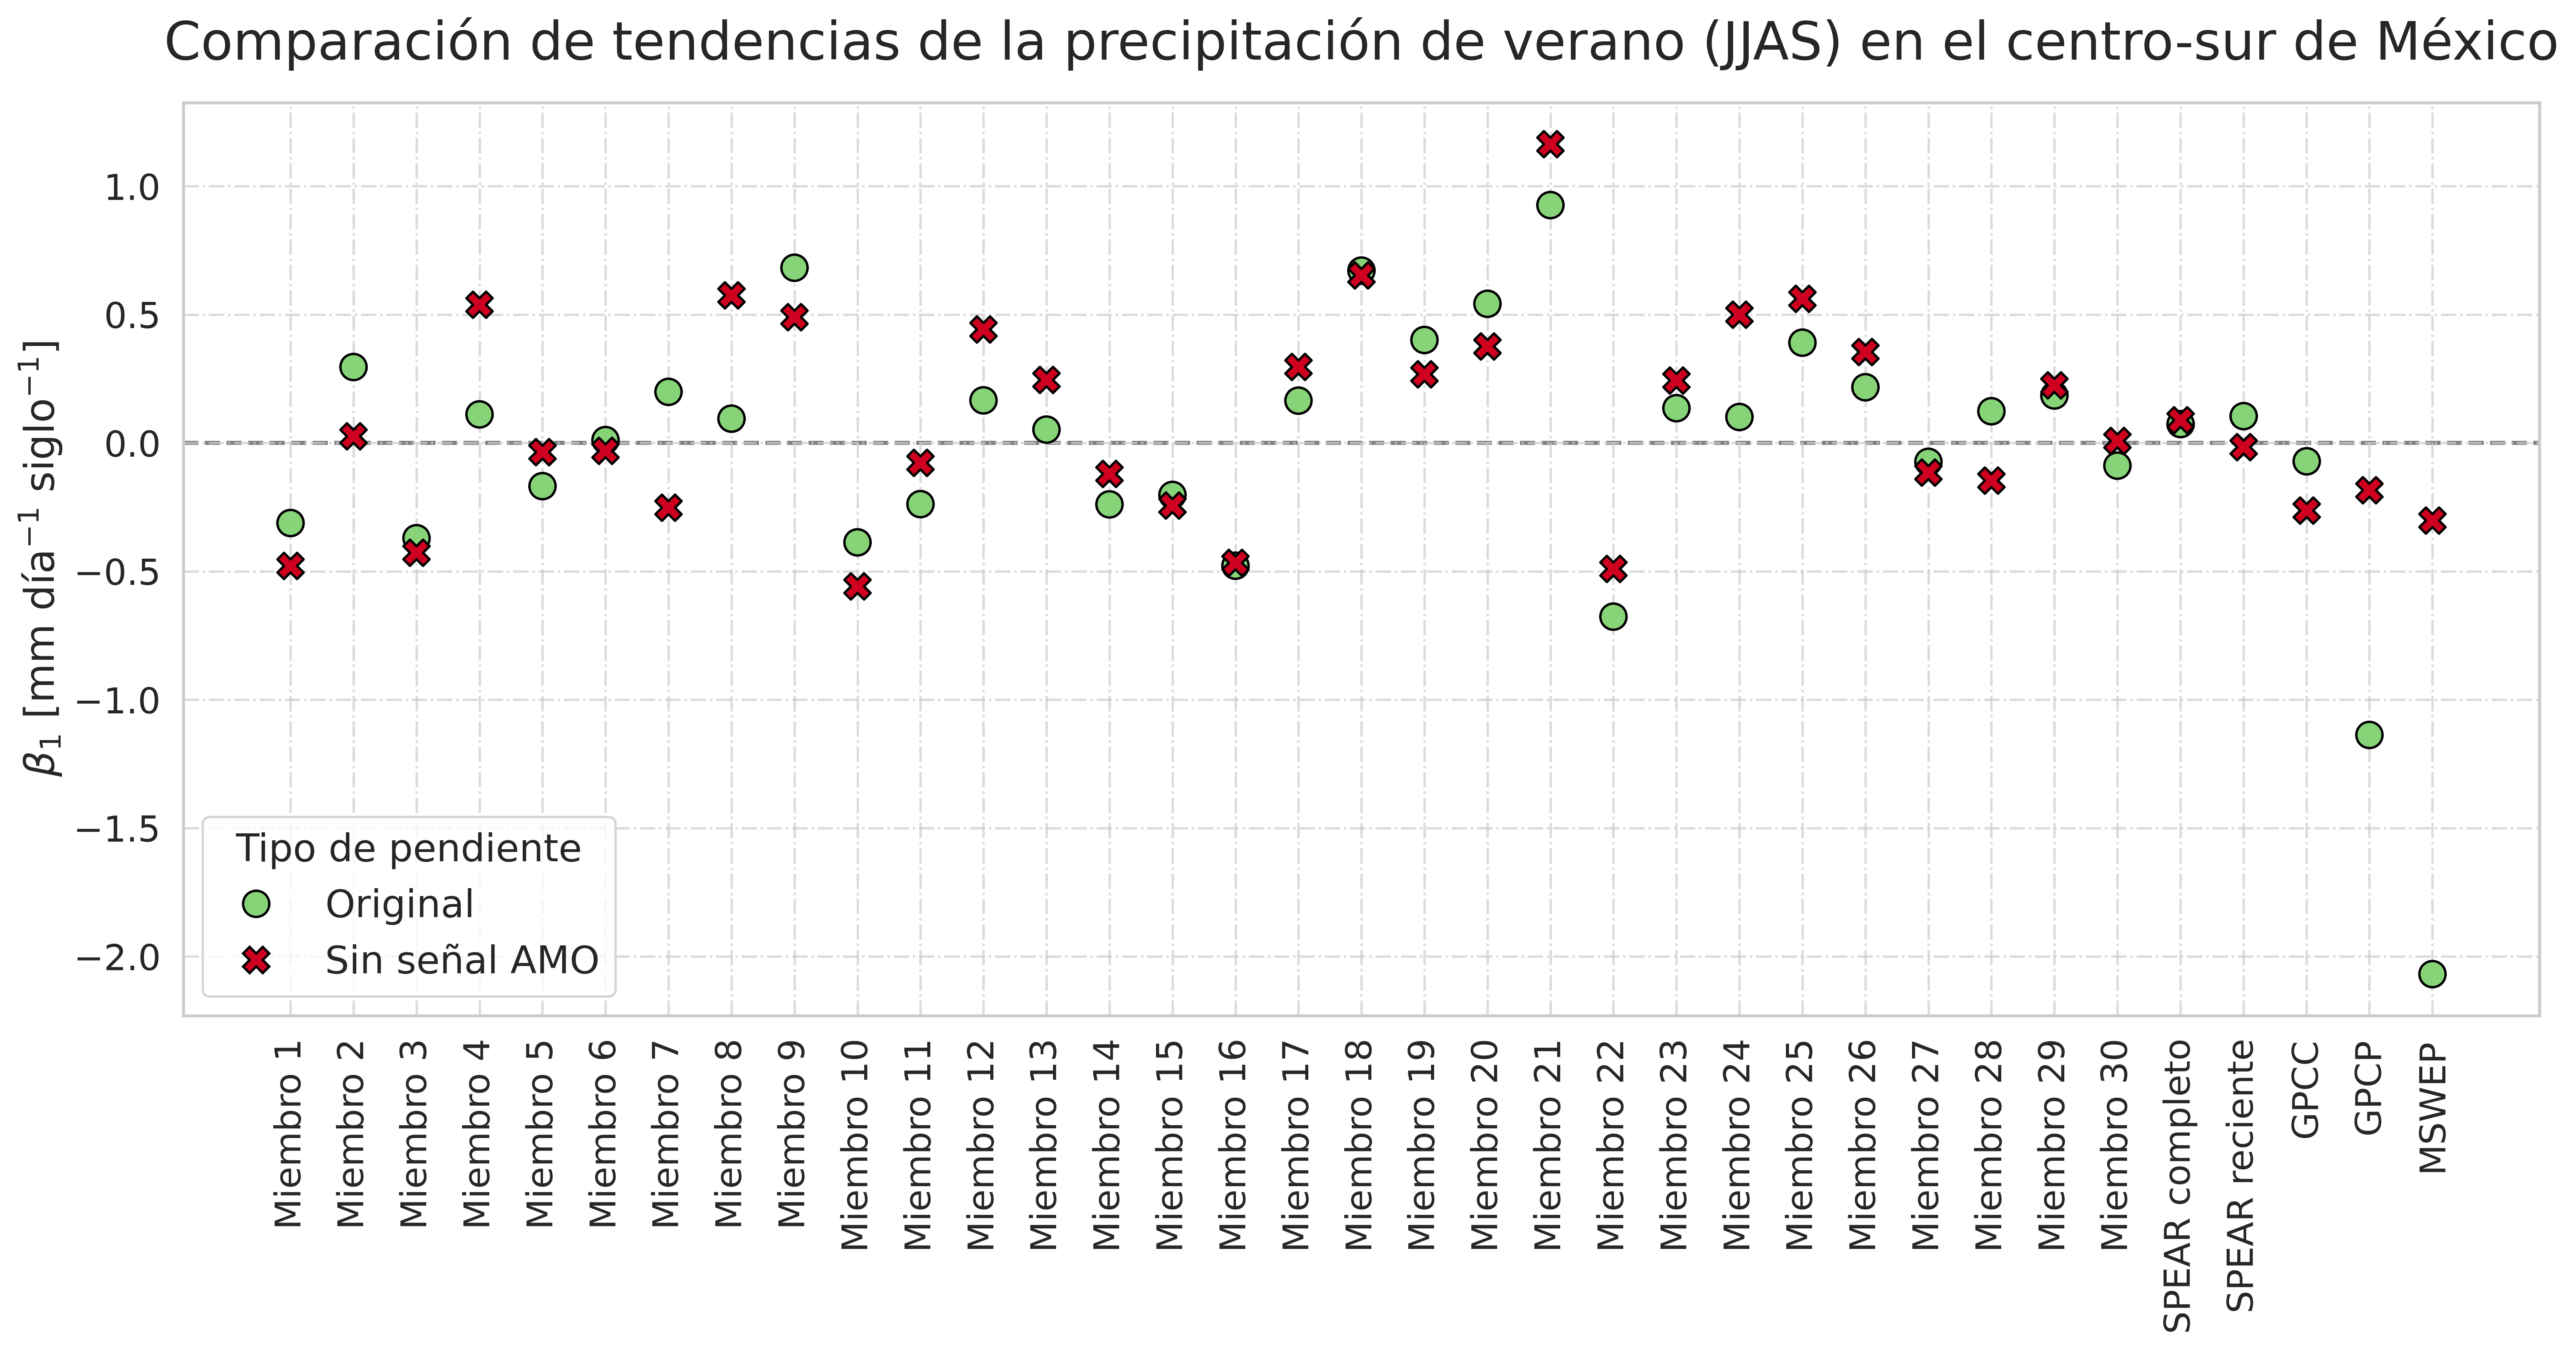

In [45]:
df = pd.DataFrame({
    "Miembro": [f"Miembro {i}" for i in range(1, 31)] * 2,
    "Pendiente": tendencias_100 + tendencias_noAMV,
    "Tipo": ["Original"] * 30 + ["Sin señal AMO"] * 30
})

markers = {"Original": "o", "Sin señal AMO": "X"}

sns.set(style="whitegrid")
plt.figure(figsize=(15, 8), dpi=500)

# orden personalizado para los miembros
orden_miembros = [f"M{i:02d}" for i in range(1, 31)]

# puntos
sns.scatterplot(data=df,x="Miembro",y="Pendiente",hue="Tipo",style="Tipo", s=120, markers=markers,
                palette={"Original": "#86D477", "Sin señal AMO": "#CF001F"}, hue_order=["Original", "Sin señal AMO"], 
                alpha=1, edgecolor="black", linewidth=1)

plt.scatter([30], pendiente_spear26, color='#86D477', s=120,edgecolor="black", linewidth=1)
plt.scatter([31], pendiente_spear80, color='#86D477', s=120,edgecolor="black", linewidth=1)
plt.scatter([32], pendiente_GPCC, color='#86D477', s=120,edgecolor="black", linewidth=1)
plt.scatter([33], pendiente_GPCP, color='#86D477', s=120,edgecolor="black", linewidth=1)
plt.scatter([34], pendiente_MSWEP, color='#86D477', s=120,edgecolor="black", linewidth=1)

plt.scatter([30], pendiente_SPEAR_26_sinAMV, color='#CF001F', s=120, marker="X",edgecolor="black", linewidth=1)
plt.scatter([31], pendiente_SPEAR_80_sinAMV, color='#CF001F', s=120, marker="X",edgecolor="black", linewidth=1)
plt.scatter([32], pendiente_GPCC_sinAMV, color='#CF001F', s=120, marker="X",edgecolor="black", linewidth=1)
plt.scatter([33], pendiente_GPCP_sinAMV, color='#CF001F', s=120, marker="X",edgecolor="black", linewidth=1)
plt.scatter([34], pendiente_MSWEP_sinAMV, color='#CF001F', s=120, marker="X",edgecolor="black", linewidth=1)


x_labels = [f"Miembro {i}" for i in range(1, 31)] + ["SPEAR completo", "SPEAR reciente", 'GPCC', 'GPCP', 'MSWEP', ]
x_positions = list(range(0, 35))
plt.xticks(ticks=x_positions, labels=x_labels, rotation=90, fontsize=14)

plt.xticks(rotation=90, fontsize=14.5)
#plt.legend([],[], frameon=False)  # patra quitar la leyenda
#plt.legend(title="Tipo de pendiente", loc="best", fontsize=14, title_fontproperties=fm.FontProperties(family='serif', size=14, weight='bold'))
plt.legend(
    title="Tipo de pendiente",loc="lower left",
    prop={'family': 'DejaVu Sans', 'size': 16},               # etiquetas
    title_fontproperties=fm.FontProperties(family="DejaVu Sans", size=16, weight='normal')  # título
)
plt.ylabel(r"$\beta_{\mathrm{1}}$ [mm día$^{-1}$ siglo$^{-1}$]", fontsize=17)
plt.grid(True, which='major', linestyle='-.', alpha=0.7)  
plt.minorticks_on()
#plt.grid(True, which='minor', linestyle='-.', alpha=0.3) 
plt.xlabel("")  # quita eje X
plt.axhline(0, color='grey', linestyle='--', linewidth=1.7, zorder=0)
plt.tick_params(axis='both', labelsize=15)  # tamaño ambos ejes
plt.title("Comparación de tendencias de la precipitación de verano (JJAS) en el centro-sur de México", fontsize=22, pad=18, x=0.5)
plt.tight_layout()
plt.show()